## Machine Learning applied to identify low hemolytic Antimicobrial Peptides

In this notebook is described all the procedure used to train and test the hemolysis model.

In [2]:
import os
import torch
import hashlib
import numpy as np
import pandas as pd
import plotnine as pln

from sklearn.svm import SVR
from sklearn.linear_model import Lasso
from sklearn.naive_bayes import GaussianNB
from sklearn import metrics
from sklearn.model_selection import train_test_split, GridSearchCV

## Helper functions

In [2]:
# This function wil convert the undefined MIC values to 100.
def convert_mic_to_numeric(mic_value):
    if type(mic_value) == str and mic_value.startswith('>'):
        mic_value = float(mic_value.replace('>', ''))
        v = 100
        return v
    else:
        return float(mic_value)

convert_mic_to_numeric('>64')

100

In [3]:
def get_correlated_columns(df, target, threshold):
    # correlating train target with train set
    corr_matrix = df.corrwith(target).abs().sort_values()

    # create a list of columns with high positive or negative correlation
    correlated_columns = []
    for column in corr_matrix.index:
        if (corr_matrix[column] >= threshold) & (column not in correlated_columns):
            correlated_columns.append(column)

    return(correlated_columns)

In [4]:
def make_seed(target_name, rep):
    s = f"{target_name}_{rep}"
    h = hashlib.md5(s.encode()).hexdigest()[:8]
    return int(h, 16)

# AMP data

In [5]:
# Load meta data
meta_data = pd.read_excel("../data/Cumulative_Peptide_data_PG1_v01.2.xlsx")
meta_data['MBC'] = [convert_mic_to_numeric(x) for x in meta_data['MBC']]

# Create the new target selectivity
meta_data['selectivity'] = meta_data['MBC'] * meta_data['%Hemolysis']
meta_data['selectivity'] = np.log10(meta_data['selectivity'])

# create activity classes
meta_data['MBC'] = meta_data['MBC'].apply(lambda x: 0 if x > 8 else 1)
meta_data

,ID,Sequence,MBC,%Hemolysis,selectivity
0,PG-1.37,HVRRLCYCRRRFCACVGS,1,2.600000,0.414973
1,PG-1.20d,RGGRLRYCRRRFCVSVGR,1,1.607281,0.507122
2,PG-1.62,RGGRLCYCRRRFCTCVGR,1,3.233927,0.810760
3,PG-1.12A,RGGRLCYCRRRACVCVGR,1,12.103021,1.383924
4,PG-1.16A,RGGRLCYCRRRFCVCAGR,1,15.821069,1.500266
...,...,...,...,...,...
88,PG-1.32,HGWRLCYCRRRFCVCVGC,0,35.460367,3.549743
89,PG-1.60,RGGRLCYCRRRFCVCVGF,0,36.664085,3.564241
90,PG-1.25,RGWRLCYCRRRFCVCVGH,0,46.397292,3.666493
91,PG-1.7,RRWCLCFCRRRFCVCVCR,0,51.181276,3.709111


## Loading Embedding

In [6]:
dir_path = '../data/embedding/esm2_15B_PG1/'

embeddings = {}
for file in os.listdir(dir_path):
    file_path = str(dir_path) + file 
    label = file.split('.pt')[0]
    embeddings[label] = torch.load(file_path, weights_only=True)['mean_representations'][48]

embed_df = pd.DataFrame.from_dict(embeddings).T.reset_index()
embed_df.rename(columns={'index': 'ID'}, inplace=True)

data = meta_data.merge(embed_df, how='inner', on='ID')
data

,ID,Sequence,MBC,%Hemolysis,selectivity,0,1,2,3,4,...,5110,5111,5112,5113,5114,5115,5116,5117,5118,5119
0,PG-1.37,HVRRLCYCRRRFCACVGS,1,2.600000,0.414973,0.056671,-0.074099,-0.040746,0.217794,-0.197767,...,-0.130863,-0.107892,0.140624,-0.169443,0.165775,-0.120193,0.094954,-0.000617,-0.199790,0.001056
1,PG-1.20d,RGGRLRYCRRRFCVSVGR,1,1.607281,0.507122,0.133009,-0.124348,-0.109747,0.222604,-0.261453,...,-0.105108,-0.053451,0.092585,-0.201894,0.094672,-0.104331,0.135752,0.036512,-0.230271,0.020399
2,PG-1.62,RGGRLCYCRRRFCTCVGR,1,3.233927,0.810760,0.155696,-0.016959,-0.179328,0.153639,-0.241203,...,-0.160722,-0.136943,0.049061,-0.175572,0.109034,-0.239965,-0.050614,-0.096664,-0.249927,0.020688
3,PG-1.12A,RGGRLCYCRRRACVCVGR,1,12.103021,1.383924,0.056310,-0.137829,-0.098538,0.162526,-0.252675,...,-0.124351,-0.181434,0.037783,-0.201551,0.092573,-0.168867,0.078524,-0.003103,-0.212419,0.049512
4,PG-1.16A,RGGRLCYCRRRFCVCAGR,1,15.821069,1.500266,0.122564,-0.024471,-0.127546,0.165324,-0.258667,...,-0.155189,-0.155856,0.061196,-0.220575,0.092058,-0.220014,0.025014,-0.053914,-0.198191,0.036471
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
88,PG-1.32,HGWRLCYCRRRFCVCVGC,0,35.460367,3.549743,0.007245,-0.115889,-0.040796,0.235570,-0.216340,...,-0.166121,-0.146094,0.080064,-0.143502,0.155125,-0.067742,0.087349,-0.027154,-0.214921,0.023557
89,PG-1.60,RGGRLCYCRRRFCVCVGF,0,36.664085,3.564241,0.143025,-0.030791,-0.110694,0.109217,-0.223111,...,-0.119124,-0.189840,-0.030339,-0.218860,0.098898,-0.174355,0.023488,-0.059298,-0.252023,0.029996
90,PG-1.25,RGWRLCYCRRRFCVCVGH,0,46.397292,3.666493,0.068697,-0.038422,-0.142241,0.184863,-0.232976,...,-0.180917,-0.172996,0.046710,-0.179037,0.106190,-0.103997,-0.029128,0.000693,-0.243295,0.019351
91,PG-1.7,RRWCLCFCRRRFCVCVCR,0,51.181276,3.709111,0.066839,-0.037917,-0.087912,0.137855,-0.218455,...,-0.167717,-0.251613,-0.086687,-0.231941,0.015133,-0.017062,0.048716,-0.028251,-0.203544,-0.114390


## Split data into train and test sets

In [ ]:
def split_data(data, target_name, seed, corr_value):   
  
    target = data[target_name]
    features = data.iloc[:, 5:]

    # Split the data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=seed)
    corr_columns = get_correlated_columns(X_train, y_train, corr_value)

    # feature selection
    XX_train = X_train[corr_columns]
    XX_test = X_test[corr_columns]

    return {'X_train':XX_train, 'X_test':XX_test, 'y_train':y_train, 'y_test': y_test}

## Running Regression Models for testing code

In [8]:
def run_cv_models(model, param_grid, target_name, corr_value):
    # store the results
    results = pd.DataFrame()

    for rep in range(100):
        seed = make_seed(target_name, rep)
        splits = split_data(data, target_name, seed, corr_value)
        X_train, X_test, y_train, y_test = splits['X_train'], splits['X_test'], splits['y_train'], splits['y_test']
        
        # search best hyperparameter 
        grid_search = GridSearchCV(model, param_grid, scoring='neg_mean_absolute_error', cv=10, n_jobs=64)
        
        # train in the whole training set
        grid_search.fit(X_train, y_train)

        # make predictions
        train_pred = grid_search.predict(X_train)
        test_y_pred = grid_search.predict(X_test)
        
        # Model evaluation on test data
        train_r2 = metrics.r2_score(y_train, train_pred)
        train_mae = metrics.mean_absolute_error(y_train, train_pred)
        train_mse = metrics.mean_squared_error(y_train, train_pred)
        train_rmse = np.sqrt(train_mse)

        # Model evaluation on test data
        test_r2 = metrics.r2_score(y_test, test_y_pred)
        test_mae = metrics.mean_absolute_error(y_test, test_y_pred)
        test_mse = metrics.mean_squared_error(y_test, test_y_pred)
        test_rmse = np.sqrt(test_mse)

        model_name = grid_search.best_estimator_.__class__.__name__
        embed_name = dir_path.split('/')[-2]
        best_params = str(grid_search.best_params_)
        
        # print best scores
        if rep % 10 == 0:
            print(f"Model: {model_name}, Train R2:{train_r2:.2f}, Test R2:{test_r2:.2f}")

        # Saving results
        res_dict = {}
        res_dict["model"] = model_name
        res_dict["replicate"] = rep
        res_dict["Embedding"] = embed_name
        
        res_dict["Train_R2_score"] = train_r2
        res_dict["Train_MAE_score"] = train_mae
        res_dict["Train_RMSE_score"] = train_rmse

        # test scores
        res_dict["Test_R2_score"] = test_r2
        res_dict["Test_MAE_score"] = test_mae
        res_dict["Test_RMSE_score"] = test_rmse

        res_dict["Test_Best_params"] = best_params
        
        # updating data frame with results
        results = pd.concat([results, pd.DataFrame(res_dict, index=[0])]).reset_index(drop=True)


    return results

## Hemolysis

In [ ]:
model = Lasso()

param_grid = {'alpha': np.arange(0.01, 1, 0.01),'max_iter': [10000, 100000]}

target_name = '%Hemolysis'
corr_value = 0.6

res_hemolysis = run_cv_models(model, param_grid, target_name, corr_value)

res_hemolysis.to_csv('results/res_cv_models_hemolysis.csv')

Model: Lasso, Train R2:0.75, Test R2:0.62
Model: Lasso, Train R2:0.76, Test R2:0.72
Model: Lasso, Train R2:0.70, Test R2:0.70
Model: Lasso, Train R2:0.76, Test R2:0.54
Model: Lasso, Train R2:0.79, Test R2:0.51
Model: Lasso, Train R2:0.75, Test R2:0.61
Model: Lasso, Train R2:0.73, Test R2:0.71
Model: Lasso, Train R2:0.76, Test R2:0.51


/stor/work/Wilke/luiz/DMS_ML_AMP/venv2/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.155e+00, tolerance: 2.984e+00
  model = cd_fast.enet_coordinate_descent(


Model: Lasso, Train R2:0.75, Test R2:0.60
Model: Lasso, Train R2:0.80, Test R2:0.58


## Selectivity

In [13]:
model = SVR()

target_name = 'selectivity'
corr_value = 0.65

param_grid =  {'C': [0.1, 1, 10, 100], 'kernel': ['linear', 'rbf', 'poly', 'sigmoid']}

res_selectivity = run_cv_models(model, param_grid, target_name, corr_value)

res_selectivity.to_csv('results/res_cv_models_selectivity.csv')

Model: SVR, Train R2:0.84, Test R2:0.71
Model: SVR, Train R2:0.92, Test R2:0.79
Model: SVR, Train R2:0.94, Test R2:0.42
Model: SVR, Train R2:0.94, Test R2:0.60
Model: SVR, Train R2:0.96, Test R2:0.48
Model: SVR, Train R2:0.84, Test R2:0.73
Model: SVR, Train R2:0.93, Test R2:0.52
Model: SVR, Train R2:0.78, Test R2:0.76
Model: SVR, Train R2:0.76, Test R2:0.79
Model: SVR, Train R2:0.63, Test R2:0.73


## Classifier for activity

In [25]:
def run_cv_models_cls(data, model, param_grid, target_name, corr_value):
    # store the results
    results = pd.DataFrame()

    for rep in range(100):
        seed = make_seed(target_name, rep)
        splits = split_data(data, target_name, seed, corr_value)
        X_train, X_test, y_train, y_test = splits['X_train'], splits['X_test'], splits['y_train'], splits['y_test']
            
        # create a GridSearchCV object with 5-fold cross-validation
        grid_search = GridSearchCV(model, param_grid, cv=10, n_jobs=10,)
        
        # fit the grid search object to the training data
        grid_search.fit(X_train.values, y_train)

        # make predictions on the test data using the best model found by the grid search
        train_y_pred = grid_search.best_estimator_.predict(X_train.values)
        test_y_pred = grid_search.best_estimator_.predict(X_test.values)
        
        model_name = grid_search.best_estimator_.__class__.__name__
        embed_name = dir_path.split('/')[-2]
        
        # evaluate the performance of the best model on the train data using accuracy score
        train_accuracy = metrics.accuracy_score(y_train, train_y_pred)
        train_recall = metrics.recall_score(y_train, train_y_pred)
        train_precision = metrics.precision_score(y_train, train_y_pred)
        train_f1_score = metrics.f1_score(y_train, train_y_pred)

        # evaluate the performance of the best model on the test data using accuracy score
        test_accuracy = metrics.accuracy_score(y_test, test_y_pred)
        test_recall = metrics.recall_score(y_test, test_y_pred)
        test_precision = metrics.precision_score(y_test, test_y_pred)
        test_f1_score = metrics.f1_score(y_test, test_y_pred)
        
        if rep % 10 ==0:
            print(f'Model: {model_name}, Train Accuracy: {train_accuracy}, Test Accuracy: {test_accuracy}')
        

        # Saving results
        res_dict = {}
        res_dict["model"] = model_name
        res_dict["replicate"] = rep
        res_dict["Embedding"] = embed_name

        res_dict["Train_Accuracy"] = train_accuracy
        res_dict["Train_recall"] = train_recall
        res_dict["Train_precision"] = train_precision
        res_dict["Train_f1"] = train_f1_score

        res_dict["Test_Accuracy"] = test_accuracy
        res_dict["Test_recall"] = test_recall
        res_dict["Test_precision"] = test_precision
        res_dict["Test_f1"] = test_f1_score

        res_dict['best_params'] = str(grid_search.best_params_)

        # updating data frame with results
        results = pd.concat([results, pd.DataFrame(res_dict, index=[0])]).reset_index(drop=True)

    return results

In [26]:
model = GaussianNB()

param_grid =  {'var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1]}

target_name = 'MBC'
corr_value = 0.3

res_MBC = run_cv_models_cls(data, model, param_grid, target_name, corr_value)
res_MBC.to_csv('results/res_cv_models_MBC.csv')

Model: GaussianNB, Train Accuracy: 0.8378378378378378, Test Accuracy: 0.6842105263157895
Model: GaussianNB, Train Accuracy: 0.7972972972972973, Test Accuracy: 0.6842105263157895
Model: GaussianNB, Train Accuracy: 0.7837837837837838, Test Accuracy: 0.631578947368421
Model: GaussianNB, Train Accuracy: 0.7837837837837838, Test Accuracy: 0.6842105263157895
Model: GaussianNB, Train Accuracy: 0.8108108108108109, Test Accuracy: 0.7894736842105263
Model: GaussianNB, Train Accuracy: 0.7972972972972973, Test Accuracy: 0.5789473684210527
Model: GaussianNB, Train Accuracy: 0.7432432432432432, Test Accuracy: 0.631578947368421
Model: GaussianNB, Train Accuracy: 0.8108108108108109, Test Accuracy: 0.631578947368421
Model: GaussianNB, Train Accuracy: 0.7567567567567568, Test Accuracy: 0.7894736842105263
Model: GaussianNB, Train Accuracy: 0.7972972972972973, Test Accuracy: 0.6842105263157895


## Results Visualization

In [3]:
res_hemolysis = pd.read_csv('../results/res_cv_models_hemolysis.csv', index_col=0)
res_selectivity = pd.read_csv('../results/res_cv_models_selectivity.csv', index_col=0)
res_MBC = pd.read_csv('../results/res_cv_models_MBC.csv', index_col=0)

/stor/work/Wilke/luiz/DMS_ML_AMP/venv2/lib/python3.10/site-packages/plotnine/layer.py:293: PlotnineWarning: stat_density : Removed 3 rows containing non-finite values.


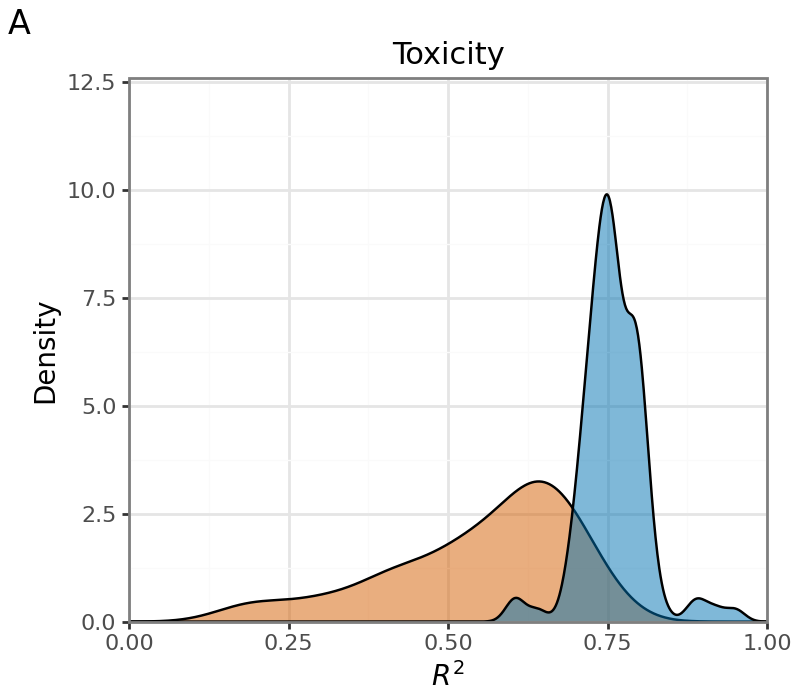

In [ ]:
res_hemolysis_long = res_hemolysis.melt(
    value_vars=['Train_R2_score', 'Test_R2_score'],
    var_name= 'Split',
    value_name='R2'
)

res_hemolysis_long['Split'] = res_hemolysis_long['Split'].str.replace('_R2_score', '')



a = (
    pln.ggplot(res_hemolysis_long, pln.aes(x='R2', fill='Split')) +
    pln.scale_fill_manual(values={"Test": "#D55E00", "Train": "#0072B2"}) +
    pln.geom_density(alpha=0.5) +
    pln.scale_y_continuous(
        limits=(0,12), 
        expand=(0, 0, 0.05, 0)) +
    pln.scale_x_continuous(
        limits=(0,1),
        expand=(0, 0, 0, 0)) +
    pln.labs(
        title= 'Toxicity',
        x="$R^2$",
        y="Density",
        tag="A") +

    pln.theme_bw(10) +
    pln.theme(
        plot_title=pln.element_text(size=11),
        figure_size=(4, 3.5),
        legend_position='none',
        legend_title=pln.element_blank())
)

a

In [6]:
res_hemolysis

,model,replicate,Embedding,Train_R2_score,Train_MAE_score,Train_RMSE_score,Test_R2_score,Test_MAE_score,Test_RMSE_score,Test_Best_params
0,Lasso,0,esm2_15B_PG1,0.746871,8.185622,10.166860,0.617375,9.980264,13.598910,"{'alpha': np.float64(0.05), 'max_iter': 10000}"
1,Lasso,1,esm2_15B_PG1,0.778920,7.641556,9.983379,0.394697,12.499298,15.075841,"{'alpha': np.float64(0.06999999999999999), 'ma..."
2,Lasso,2,esm2_15B_PG1,0.798351,7.380499,9.370224,0.612649,10.362578,13.083990,"{'alpha': np.float64(0.04), 'max_iter': 10000}"
3,Lasso,3,esm2_15B_PG1,0.726313,8.129976,10.226329,0.700452,11.427296,13.952456,"{'alpha': np.float64(0.04), 'max_iter': 10000}"
4,Lasso,4,esm2_15B_PG1,0.746194,8.024679,10.461912,0.638553,9.797557,12.621067,"{'alpha': np.float64(0.060000000000000005), 'm..."
...,...,...,...,...,...,...,...,...,...,...
95,Lasso,95,esm2_15B_PG1,0.763576,8.487198,10.919362,0.267490,9.423581,10.854618,"{'alpha': np.float64(0.060000000000000005), 'm..."
96,Lasso,96,esm2_15B_PG1,0.722688,8.189089,10.826509,0.677992,9.921888,12.602065,"{'alpha': np.float64(0.060000000000000005), 'm..."
97,Lasso,97,esm2_15B_PG1,0.746571,8.153164,10.515390,0.562850,11.036365,13.635210,"{'alpha': np.float64(0.06999999999999999), 'ma..."
98,Lasso,98,esm2_15B_PG1,0.761072,8.182708,10.557841,0.164412,11.607526,14.919519,"{'alpha': np.float64(0.05), 'max_iter': 10000}"


In [11]:
res_hemolysis_long.groupby('Split')['R2'].median()

Split
Test     0.586426
Train    0.756186
Name: R2, dtype: float64

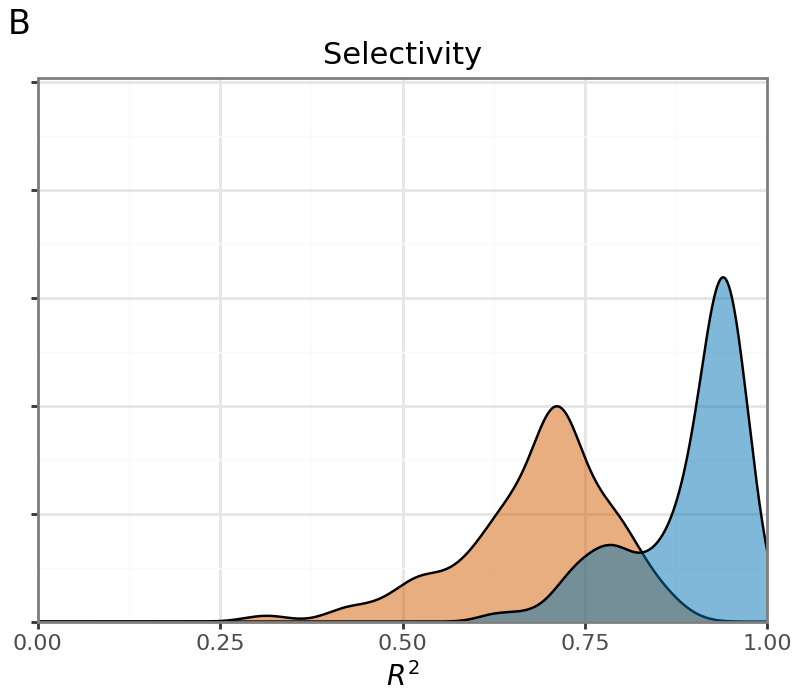

In [4]:
res_selectivity_long = res_selectivity.melt(
    value_vars=['Train_R2_score', 'Test_R2_score'],
    var_name= 'Split',
    value_name='R2'
)
res_selectivity_long['Split'] = res_selectivity_long['Split'].str.replace('_R2_score', '')



b = (
    pln.ggplot(res_selectivity_long, pln.aes(x='R2', fill='Split')) +
    pln.scale_fill_manual(values={"Test": "#D55E00", "Train": "#0072B2"}) +
    pln.geom_density(alpha=0.5) +
    pln.scale_y_continuous(
        limits=(0,12), 
        expand=(0, 0, 0.05, 0)) +
    pln.scale_x_continuous(
        limits=(0,1),
        expand=(0, 0, 0, 0)) +
    pln.labs(
        title= 'Selectivity',
        x="$R^2$",
        y="",
        tag="B") +
    pln.theme_bw(10) +
    pln.theme(
        plot_title=pln.element_text(size=11),
        axis_text_y=pln.element_blank(),
        #axis_ticks_major_y=pln.element_blank(),
        #axis_ticks_minor_y=pln.element_blank(),
        figure_size=(4, 3.5),
        legend_position='none',
        legend_title=pln.element_blank())
)

b

In [5]:
res_selectivity_long.groupby('Split')['R2'].mean()

Split
Test     0.685049
Train    0.892825
Name: R2, dtype: float64

In [13]:
res_selectivity_long.groupby('Split')['R2'].median()

Split
Test     0.703029
Train    0.926481
Name: R2, dtype: float64

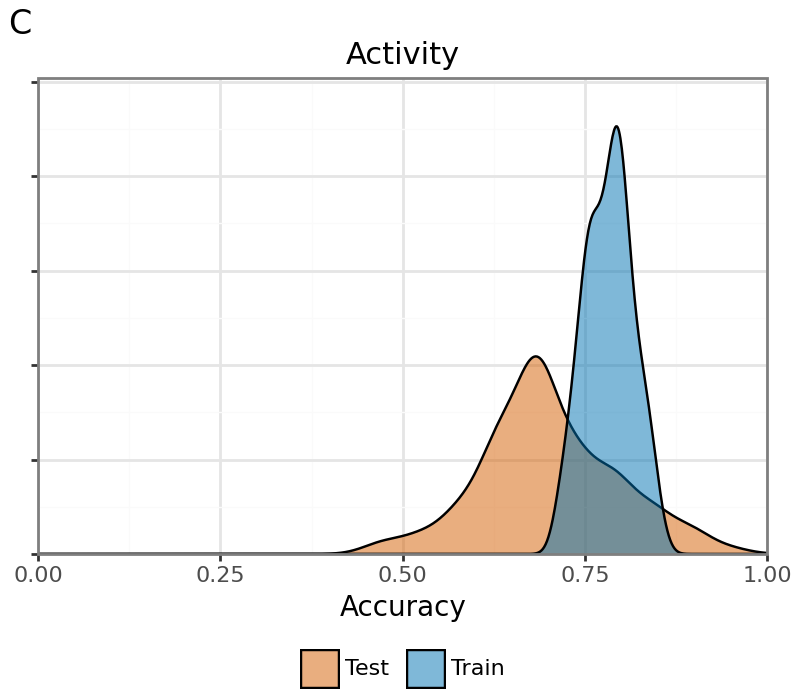

In [20]:
res_MBC_long = res_MBC.melt(
    value_vars=['Train_Accuracy', 'Test_Accuracy'],
    var_name= 'Split',
    value_name='Accuracy'
)
res_MBC_long['Split'] = res_MBC_long['Split'].str.replace('_Accuracy', '')


c = (
    pln.ggplot(res_MBC_long, pln.aes(x='Accuracy', fill='Split')) +
    pln.scale_fill_manual(values={"Test": "#D55E00", "Train": "#0072B2"}) +
    pln.geom_density(alpha=0.5) +
    pln.scale_y_continuous(
        limits=(0,12), 
        expand=(0, 0, 0.05, 0)) +
    pln.scale_x_continuous(
        limits=(0,1),
        expand=(0, 0, 0, 0)) +
    pln.labs(
        title= 'Activity',
        x="Accuracy",
        y="",
        tag="C"
        ) +
    pln.theme_bw(10) +
    pln.theme(
        plot_title=pln.element_text(size=11),
        axis_text_y=pln.element_blank(),
        figure_size=(4, 3.5),
        legend_position='bottom',
        legend_title=pln.element_blank())
)

c

In [15]:
res_MBC_long.groupby('Split')['Accuracy'].median()

Split
Test     0.684211
Train    0.783784
Name: Accuracy, dtype: float64

/stor/work/Wilke/luiz/DMS_ML_AMP/venv2/lib/python3.10/site-packages/plotnine/layer.py:293: PlotnineWarning: stat_density : Removed 3 rows containing non-finite values.
/stor/work/Wilke/luiz/DMS_ML_AMP/venv2/lib/python3.10/site-packages/plotnine/layer.py:293: PlotnineWarning: stat_density : Removed 3 rows containing non-finite values.


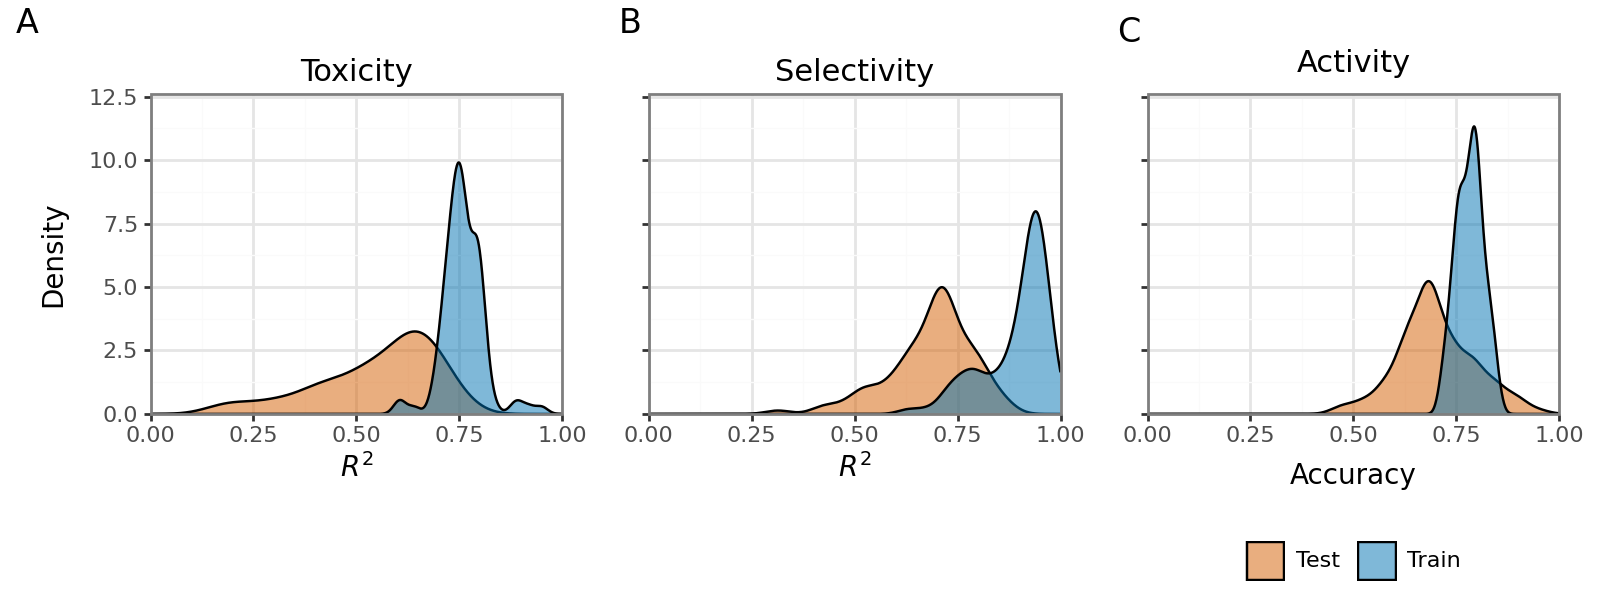

In [24]:
comp = a | b | c
plot = comp + pln.theme(figure_size=(8, 3))
plot.save('../results/figures/comp_Low-N_res_v02.png', dpi=600)
plot